In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve

# SVM 

In [73]:
Data= pd.read_csv(r"C:\Users\Harsh\OneDrive\Desktop\DATASETS\900D_heart_disease_dataset.csv")
Test_Data = pd.read_csv(r"C:\Users\Harsh\OneDrive\Desktop\DATASETS\100D_test_dataset.csv")

In [74]:
X_test = Test_Data.drop("target", axis=1)
y_test = Test_Data["target"]

In [75]:
X_train = Data.drop("target", axis=1)
y_train = Data["target"]

In [76]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [77]:
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale',probability=True)  
svm_clf.fit(X_train, y_train)

SVC(probability=True)

In [78]:
y_pred = svm_clf.predict(X_test)
y_prob = svm_clf.predict_proba(X_test)[:, 1]

In [79]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

In [80]:
results = {"Accuracy": acc, "Precision": prec, "Recall": rec, "AUC": auc, "fpr_tpr": roc_curve(y_test, y_prob)}

In [81]:
results

{'Accuracy': 0.95,
 'Precision': 0.9565217391304348,
 'Recall': 0.9361702127659575,
 'AUC': 0.9723002810116419,
 'fpr_tpr': (array([0.        , 0.        , 0.        , 0.        , 0.01886792,
         0.01886792, 0.01886792, 0.01886792, 0.01886792, 0.01886792,
         0.01886792, 0.01886792, 0.01886792, 0.03773585, 0.03773585,
         0.13207547, 0.16981132, 0.20754717, 0.24528302, 0.43396226,
         0.47169811, 0.62264151, 0.62264151, 0.71698113, 0.75471698,
         0.90566038, 0.94339623, 1.        ]),
  array([0.        , 0.04255319, 0.14893617, 0.27659574, 0.27659574,
         0.36170213, 0.40425532, 0.70212766, 0.74468085, 0.78723404,
         0.82978723, 0.87234043, 0.91489362, 0.91489362, 0.9787234 ,
         0.9787234 , 0.9787234 , 0.9787234 , 0.9787234 , 0.9787234 ,
         0.9787234 , 0.9787234 , 1.        , 1.        , 1.        ,
         1.        , 1.        , 1.        ]),
  array([       inf, 0.99667379, 0.99215022, 0.98952203, 0.98340053,
         0.98033473, 0.9

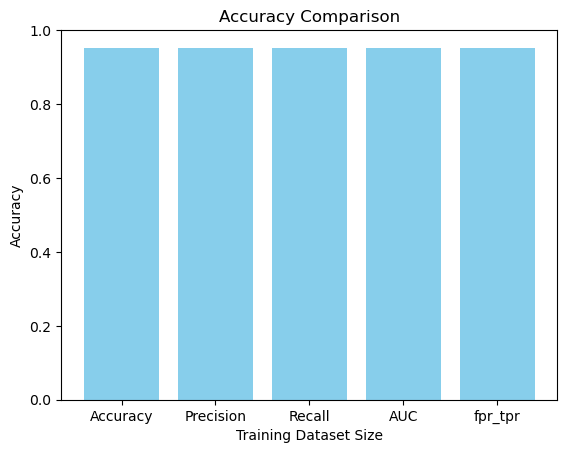

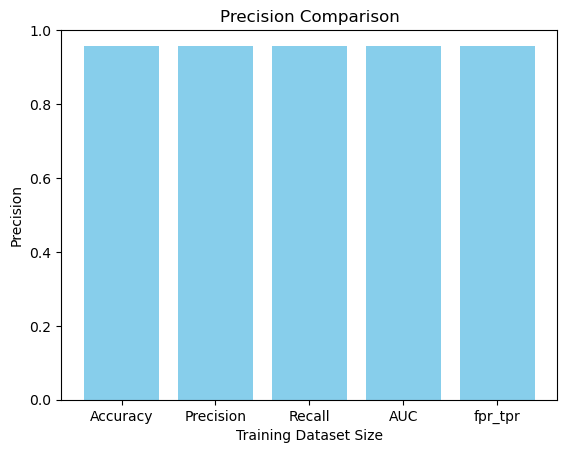

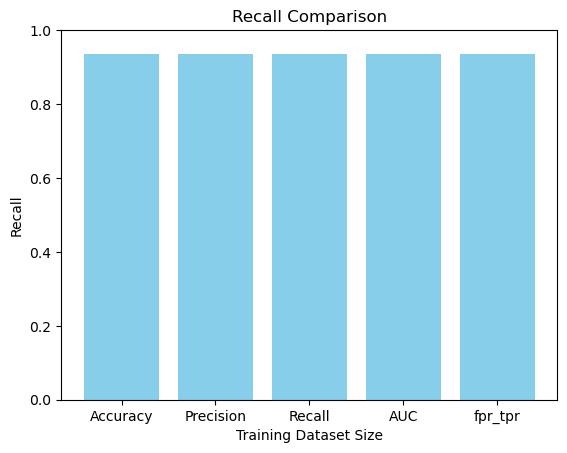

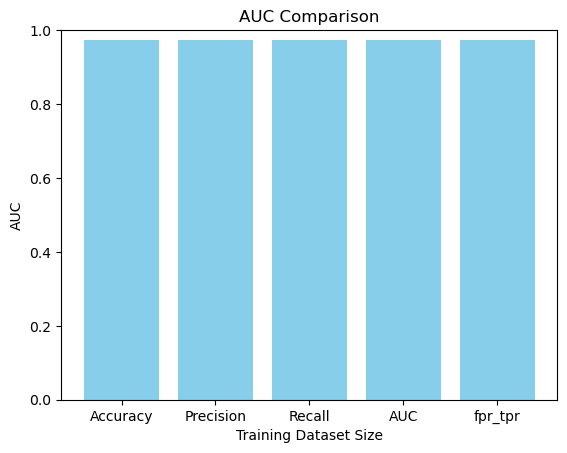

In [82]:
metrics = ["Accuracy", "Precision", "Recall", "AUC"]
for metric in metrics:
    plt.figure()
    plt.bar(results.keys(), [results[metric] for size in results], color="skyblue")
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.xlabel("Training Dataset Size")
    plt.ylim(0, 1)
    plt.show()

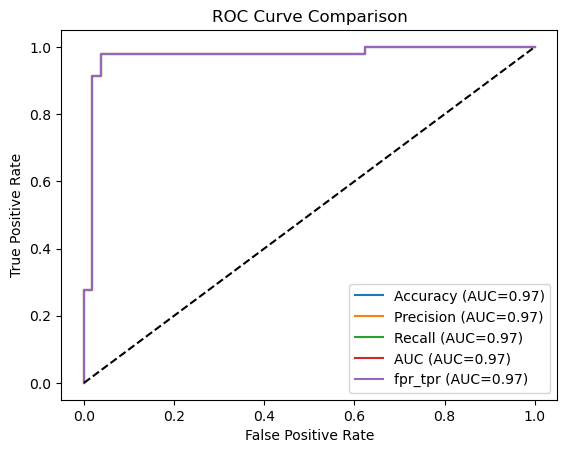

In [83]:
plt.figure()
for size in results:
    fpr, tpr, _ = results["fpr_tpr"]
    plt.plot(fpr, tpr, label=f"{size} (AUC={results['AUC']:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

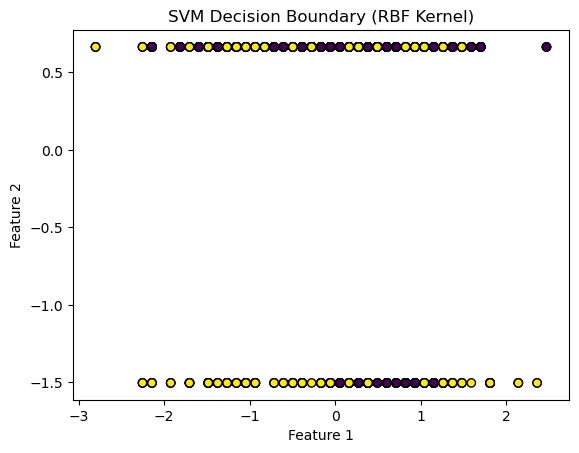

In [84]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Decision Boundary (RBF Kernel)')
plt.show()

# Random forest 

In [85]:
from sklearn.ensemble import RandomForestClassifier

In [86]:
rf_clf = RandomForestClassifier(n_estimators=100,criterion='gini',max_depth=None,random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [87]:
y_pred = rf_clf.predict(X_test)
y_prob = rf_clf.predict_proba(X_test)[:, 1]

In [88]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

In [89]:
rec,acc,prec,auc

(1.0, 1.0, 1.0, 1.0)

    Importance
2     0.160296
7     0.123297
9     0.116786
11    0.110517
12    0.102168
0     0.085894
4     0.078522
3     0.064671
10    0.048671
8     0.046406
1     0.037236
6     0.016868
5     0.008668


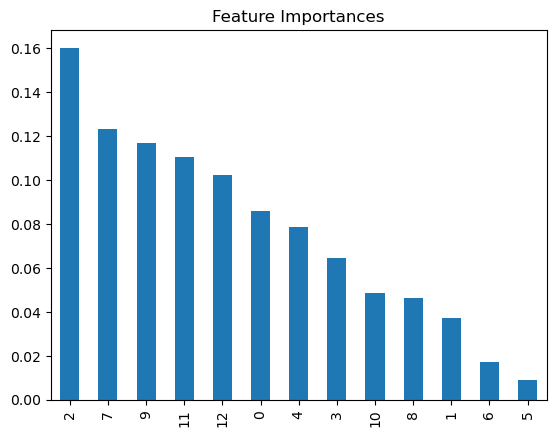

In [90]:
feature_importances = pd.DataFrame(
    rf_clf.feature_importances_,
    columns=["Importance"]
).sort_values("Importance", ascending=False)

print(feature_importances)

feature_importances.plot(kind="bar", legend=False)
plt.title("Feature Importances")
plt.show()
